# Calibrate Oil & Gas sector BAU to match Libya CCD 2026-03 targets

**Problem.** The current BAU (strategy 0) in SISEPUEDE produces a fugitive-emissions trajectory that peaks around 2031-2032 and *declines* to ~2036, driven by three things baked into `sisepuede_raw_inputs_recalibrated_lvst_cc_soil_fert.csv`:

1. Crude oil exports that peak in 2035 (3,214 PJ) and then decline modestly to 2050.
2. INEN / SCOE fuel-mix fractions that progressively electrify after 2028 (built-in SSP default descent for `natural_gas` and `oil`).
3. An abrupt retirement of `residual_capacity_pp_gas_gw` from 10 GW (2024) to 2.5 GW (2030) to 1 GW (2035+).

However, the **Libya Climate Diagnostic — Oil & Gas Sector (March 2026)** document describes a BAU that *grows* flaring volumes and emissions monotonically to 2030, with crude oil production reaching ~1.9–2.0 mb/d and flaring volumes reaching 992 MMcfd (26.65 Mt CO₂e of flaring emissions) by 2030 — no abatement, no electrification assumption.

**Goal.** Build a new input CSV whose BAU path matches the document's narrative for 2015–2030, and extends to 2050 with a defensible plateau consistent with Libya's 2 mb/d aspiration. We keep the three post-2030 inflection drivers *controllable* via parameters, so we can later tune to the published BAU curve shape.

**What this notebook changes (BAU only — does not touch mitigation levers):**

| Variable | Current (2030) | New (2030 target) | Driver |
| --- | --- | --- | --- |
| `exports_enfu_pj_fuel_crude` | 2,776 PJ | ~3,530 PJ | Scale to 1.9 mb/d production @ 83% export ratio |
| `exports_enfu_pj_fuel_natural_gas` | 137 PJ | ~290 PJ | Add Structures A&E output (+7.8 Bcm/yr by 2026) |
| `frac_fgtv_drained_and_waste_ch4_flared_fuel_crude` | 0.34 (flat) | 0.34 (kept) | Controls split between flared vs vented CH₄ |
| `frac_inen_energy_*_natural_gas`, `frac_inen_energy_*_oil`, `frac_scoe_heat_energy_*_natural_gas` | decline post-2028 | **frozen at 2028 values** | Removes built-in electrification from BAU |

**What this notebook does NOT change:**

- `ef_fgtv_*` emission factors (stay constant; mitigation should come from transformations, not the baseline).
- `frac_fgtv_capture_associated_gas_fuel_*` (GFR lever; stays 0 in BAU by design).
- `frac_fgtv_reduction_in_fugitive_leaks` (stays 0 in BAU).
- NEMOMod `residual_capacity_pp_gas_gw` retirement schedule (that is a domestic power-grid assumption, orthogonal to upstream flaring).

**Inputs/outputs**

- Input: `sisepuede_raw_inputs_recalibrated_lvst_cc_soil_fert.csv`
- Output: `sisepuede_raw_inputs_oilgas_bau_calibrated.csv`

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
# Parameters
INPUT_FILE = "sisepuede_raw_inputs_recalibrated_lvst_cc_soil_fert.csv"
OUTPUT_FILE = "sisepuede_raw_inputs_oilgas_bau_calibrated.csv"

BASE_YEAR = 2015
ANCHOR_YEAR = 2024        # last year with observed data in the CCD document
DOC_END_YEAR = 2030       # last year explicitly projected in the CCD document
END_YEAR = 2050

# Energy-content constants (LHV)
GJ_PER_BBL_CRUDE = 6.119          # 1 bbl crude ≈ 5.8 MMBtu ≈ 6.119 GJ
MJ_PER_M3_NATGAS = 36.6            # LHV of natural gas, MJ per m3
CF_PER_M3 = 35.3147                # 1 m3 = 35.3147 ft3
DAYS_PER_YEAR = 365.0

# Libya crude: exports are a large fraction of production (FRED 2024: 0.97 mb/d exports vs 1.16 mb/d prod)
EXPORT_SHARE_CRUDE = 0.83

# Post-2030 BAU extension: the CCD document stops at 2030. We want a gentle decline that
# brings 2050 fugitive emissions back to the 2026 engineered-BAU level (~-28% vs 2030 peak).
# A compound annual change of -0.017 gives (1-0.017)^20 ≈ 0.71 at 2050, i.e. -29%.
POST_2030_OIL_ANNUAL_CHANGE = -0.017    # -1.7%/yr on crude production / exports after 2030
POST_2030_GAS_ANNUAL_CHANGE = -0.017    # apply same slope to NG to drive fugitive down symmetrically

In [18]:
# Document targets (CCD March 2026, charts 2 and 5, both BAU series)
# Oil production is kb/d (see chart 2). Flaring volumes are MMcfd (chart 2, BAU series).
# Flaring emissions are Mt CO2e (chart 5, BAU series).
DOC_BAU = pd.DataFrame({
    "year": list(range(2015, 2031)),
    "oil_kbd": [463.97, 444.69, 878.89, 1026.96, 1168.67, 408.07, 1237.81, 1057.89,
                1225.43, 1163.27, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0],
    "flaring_mmcfd_bau": [252.74, 225.47, 378.15, 453.01, 495.77, 239.34, 580.37, 524.45,
                          658.05, 607.13, 730.81, 783.01, 835.21, 887.41, 939.61, 991.81],
    "flaring_emis_mt_bau": [6.79, 6.06, 10.16, 12.17, 13.32, 6.43, 15.60, 14.09,
                            17.68, 16.32, 19.64, 21.04, 22.44, 23.85, 25.25, 26.65],
})
DOC_BAU

,year,oil_kbd,flaring_mmcfd_bau,flaring_emis_mt_bau
0,2015,463.97,252.74,6.79
1,2016,444.69,225.47,6.06
2,2017,878.89,378.15,10.16
3,2018,1026.96,453.01,12.17
4,2019,1168.67,495.77,13.32
5,2020,408.07,239.34,6.43
6,2021,1237.81,580.37,15.60
7,2022,1057.89,524.45,14.09
8,2023,1225.43,658.05,17.68
9,2024,1163.27,607.13,16.32


In [19]:
df = pd.read_csv(INPUT_FILE)
assert "year" in df.columns and "time_period" in df.columns
assert (df["year"] == df["time_period"] + BASE_YEAR).all()
print(f"Shape: {df.shape}  |  Years: {df['year'].min()}-{df['year'].max()}")

VARS_CRUDE = ["exports_enfu_pj_fuel_crude"]
VARS_NG = ["exports_enfu_pj_fuel_natural_gas"]
VARS_FGTV = [
    "frac_fgtv_drained_and_waste_ch4_flared_fuel_crude",
    "frac_fgtv_drained_and_waste_ch4_flared_fuel_oil",
    "frac_fgtv_reduction_in_fugitive_leaks",
    "frac_fgtv_capture_associated_gas_fuel_crude",
    "frac_fgtv_capture_associated_gas_fuel_oil",
]
assert all(c in df.columns for c in VARS_CRUDE + VARS_NG + VARS_FGTV)

df[["year"] + VARS_CRUDE + VARS_NG].set_index("year").loc[[2024, 2030, 2035, 2040, 2050]]

Shape: (36, 2441)  |  Years: 2015-2050


,exports_enfu_pj_fuel_crude,exports_enfu_pj_fuel_natural_gas
year,,
2024,2251.037960,86.184000
2030,2776.272727,137.272727
2035,3214.000000,180.000000
2040,3182.000000,186.666667
2050,3118.000000,200.000000


## Step 1 — Convert document targets to SSP input units

- **Crude production**: `kb/d → PJ/yr`   `PJ = kb/d * 1e3 * 365 * 6.119 / 1e6`
- **Crude exports** (what SSP actually consumes): `production_PJ * EXPORT_SHARE_CRUDE`
- **Natural gas**: marketed output in the document is 16.41 Bcm in 2024. Exports in the input are 86 PJ in 2024; the rest is domestic demand. We keep exports as the lever because domestic NG demand is derived endogenously in SSP.
- **Flaring volume**: `MMcfd → Bcm/yr → PJ/yr` for sanity-checks against fugitive emissions. We do NOT inject flaring volume directly; instead we let SSP recompute it from crude production × EF × flaring-fraction.

In [20]:
def kbd_to_pj_per_yr(kbd):
    # kb/d * 1000 bbl/kb * 365 d/yr * 6.119 GJ/bbl / 1e6 GJ/PJ
    return kbd * 1e3 * DAYS_PER_YEAR * GJ_PER_BBL_CRUDE / 1e6

def mmcfd_to_bcm_per_yr(mmcfd):
    # MMcfd * 1e6 cf/d * 365 d/yr / 35.3147 cf/m3 / 1e9 m3/Bcm
    return mmcfd * 1e6 * DAYS_PER_YEAR / CF_PER_M3 / 1e9

def mmcfd_to_pj_per_yr(mmcfd):
    bcm = mmcfd_to_bcm_per_yr(mmcfd)
    return bcm * 1e9 * MJ_PER_M3_NATGAS / 1e9   # Bcm * 1e9 m3/Bcm * 36.6 MJ/m3 / 1e9 MJ/PJ

DOC_BAU["crude_prod_pj"] = kbd_to_pj_per_yr(DOC_BAU["oil_kbd"])
DOC_BAU["crude_exports_pj_target"] = DOC_BAU["crude_prod_pj"] * EXPORT_SHARE_CRUDE
DOC_BAU["flaring_pj_per_yr"] = mmcfd_to_pj_per_yr(DOC_BAU["flaring_mmcfd_bau"])
DOC_BAU.round(1)

,year,oil_kbd,flaring_mmcfd_bau,flaring_emis_mt_bau,crude_prod_pj,crude_exports_pj_target,flaring_pj_per_yr
0,2015,464.0,252.7,6.8,1036.2,860.1,95.6
1,2016,444.7,225.5,6.1,993.2,824.3,85.3
2,2017,878.9,378.2,10.2,1962.9,1629.2,143.0
3,2018,1027.0,453.0,12.2,2293.6,1903.7,171.4
4,2019,1168.7,495.8,13.3,2610.1,2166.4,187.5
5,2020,408.1,239.3,6.4,911.4,756.5,90.5
6,2021,1237.8,580.4,15.6,2764.6,2294.6,219.5
7,2022,1057.9,524.4,14.1,2362.7,1961.1,198.4
8,2023,1225.4,658.0,17.7,2736.9,2271.6,248.9
9,2024,1163.3,607.1,16.3,2598.1,2156.4,229.7


In [21]:
# Sanity check against the current input at 2024 (anchor year)
current_2024_exports = float(df.loc[df.year == 2024, "exports_enfu_pj_fuel_crude"].iloc[0])
doc_2024_exports = float(DOC_BAU.loc[DOC_BAU.year == 2024, "crude_exports_pj_target"].iloc[0])
print(f"Crude exports 2024  |  current input: {current_2024_exports:,.0f} PJ  |  doc-implied @ 83%: {doc_2024_exports:,.0f} PJ  |  ratio: {current_2024_exports/doc_2024_exports:.2f}")
# The current input slightly understates 2024 export volume vs the doc's implied 1.16 mb/d * 83%. This is
# expected because the doc reports production, and historical exports were lower (~970 kb/d in 2024 per FRED).

Crude exports 2024  |  current input: 2,251 PJ  |  doc-implied @ 83%: 2,156 PJ  |  ratio: 1.04


## Step 2 — Build the target export trajectory (2015-2050)

Rules:

- `year < 2024`: keep the current input unchanged (historical calibration to FRED data done already).
- `2024 ≤ year ≤ 2030`: override with the document's BAU trajectory (linearly ramps from 1.16 mb/d to 1.9 mb/d for oil, from 86 PJ to our 2030 NG target).
- `year > 2030`: plateau at 2030 value with an optional annual drift (`POST_2030_*_ANNUAL_CHANGE`).

In [22]:
def build_trajectory(years, historical_series, doc_values, post_2030_annual_change):
    """Splice historical + document + plateau-with-drift trajectories."""
    years = np.asarray(years)
    hist = pd.Series(historical_series, index=years).astype(float)
    doc = pd.Series(doc_values, index=doc_values.index).astype(float)
    out = hist.copy()
    # Overwrite 2024-2030 with document targets (where available)
    common = sorted(set(doc.index) & set(out.index) & set(range(ANCHOR_YEAR, DOC_END_YEAR + 1)))
    for y in common:
        out[y] = doc[y]
    # Plateau with optional drift for 2031+
    v_2030 = out[DOC_END_YEAR]
    for y in range(DOC_END_YEAR + 1, END_YEAR + 1):
        dy = y - DOC_END_YEAR
        out[y] = v_2030 * (1.0 + post_2030_annual_change) ** dy
    return out.reindex(years)


# Crude exports (PJ)
doc_crude_exports = DOC_BAU.set_index("year")["crude_exports_pj_target"]
new_crude_exports = build_trajectory(
    years=df["year"].values,
    historical_series=df["exports_enfu_pj_fuel_crude"].values,
    doc_values=doc_crude_exports,
    post_2030_annual_change=POST_2030_OIL_ANNUAL_CHANGE,
)

# Natural gas exports (PJ). The document says Structures A&E adds ~7.8 Bcm/yr by 2026.
# 7.8 Bcm * 1e9 m3 * 36.6 MJ/m3 / 1e9 = 285 PJ potential. Assume 50% of this goes to exports by 2030.
ng_export_2030_target_pj = 290.0   # engineering assumption; adjust to taste
doc_ng_series = df.set_index("year")["exports_enfu_pj_fuel_natural_gas"].copy()
# Linear ramp 2024 -> 2030 from current 2024 value to target
ng_2024 = float(doc_ng_series[ANCHOR_YEAR])
for y in range(ANCHOR_YEAR + 1, DOC_END_YEAR + 1):
    f = (y - ANCHOR_YEAR) / (DOC_END_YEAR - ANCHOR_YEAR)
    doc_ng_series[y] = ng_2024 + f * (ng_export_2030_target_pj - ng_2024)
new_ng_exports = build_trajectory(
    years=df["year"].values,
    historical_series=df["exports_enfu_pj_fuel_natural_gas"].values,
    doc_values=doc_ng_series,
    post_2030_annual_change=POST_2030_GAS_ANNUAL_CHANGE,
)

pd.DataFrame({
    "year": df["year"],
    "crude_exp_old": df["exports_enfu_pj_fuel_crude"].values,
    "crude_exp_new": new_crude_exports.values,
    "ng_exp_old": df["exports_enfu_pj_fuel_natural_gas"].values,
    "ng_exp_new": new_ng_exports.values,
}).set_index("year").loc[[2020, 2024, 2026, 2028, 2030, 2035, 2040, 2050]].round(1)

,crude_exp_old,crude_exp_new,ng_exp_old,ng_exp_new
year,,,,
2020,2251.0,2251.0,153.9,153.9
2024,2251.0,2156.4,86.2,86.2
2026,2426.1,2780.6,103.1,154.1
2028,2601.2,3151.4,120.2,222.1
2030,2776.3,3522.1,137.3,290.0
2035,3214.0,3232.8,180.0,266.2
2040,3182.0,2967.2,186.7,244.3
2050,3118.0,2499.6,200.0,205.8


## Step 3 — Freeze domestic fuel-mix fractions under BAU

The current input has INEN and SCOE `natural_gas` / `oil` fractions declining gradually after 2028 (this is the SSP default descent reflecting global electrification). That is an *implicit* mitigation and is inconsistent with the CCD document's BAU which assumes no change. We freeze those fractions at their 2028 values from 2028 onward.

To preserve mass-balance (fractions summing to 1 within each sector), we proportionally rescale the corresponding `*_electricity` / `*_biomass` / other fractions downward by the same amount they were being increased.

In [23]:
FREEZE_YEAR = 2028

INEN_FUELS = ["natural_gas", "hydrocarbon_gas_liquids", "solid_biomass", "biomass", "biofuels",
              "coal", "coke", "electricity", "hydrogen", "oil", "kerosene", "diesel", "gasoline",
              "solar", "blast_furnace_gas", "geothermal"]
SCOE_FUELS = ["natural_gas", "hydrocarbon_gas_liquids", "solid_biomass", "coal", "electricity",
              "hydrogen", "kerosene", "diesel", "gasoline"]

def _match_fuel(rest, fuels):
    # Match longest suffix first so 'natural_gas' wins over 'gas'.
    for fuel in sorted(fuels, key=len, reverse=True):
        if rest.endswith("_" + fuel):
            return fuel
    return None

def find_fuelmix_groups(cols):
    groups = {}
    for c in cols:
        if c.startswith("frac_inen_energy_"):
            rest = c[len("frac_inen_energy_"):]
            fuel = _match_fuel(rest, INEN_FUELS)
            if fuel is not None:
                subsector = rest[: -len("_" + fuel)]
                groups.setdefault(("inen", subsector), []).append((fuel, c))
        elif c.startswith("frac_scoe_heat_energy_"):
            rest = c[len("frac_scoe_heat_energy_"):]
            fuel = _match_fuel(rest, SCOE_FUELS)
            if fuel is not None:
                subsector = rest[: -len("_" + fuel)]
                groups.setdefault(("scoe", subsector), []).append((fuel, c))
    return groups

groups = find_fuelmix_groups(df.columns)
print(f"Found {len(groups)} fuel-mix groups (sector, subsector). Sample:")
for k in list(groups)[:4]:
    print(" ", k, "->", len(groups[k]), "fuel columns")

Found 24 fuel-mix groups (sector, subsector). Sample:
  ('inen', 'agriculture_and_livestock') -> 12 fuel columns
  ('inen', 'cement') -> 12 fuel columns
  ('inen', 'chemicals') -> 12 fuel columns
  ('inen', 'electronics') -> 12 fuel columns


In [24]:
# Sanity check: for each group, columns should sum to ~1.0 at each year.
sample_group = list(groups)[0]
sample_cols = [c for _, c in groups[sample_group]]
sums = df[sample_cols].sum(axis=1)
print(f"Sample group {sample_group}: sum range {sums.min():.4f} to {sums.max():.4f}")

Sample group ('inen', 'agriculture_and_livestock'): sum range 0.9749 to 0.9956


In [25]:
def freeze_bau_fuel_mix(df, groups, freeze_year, fossil_fuels=("natural_gas", "oil", "coal", "diesel",
                                                               "gasoline", "kerosene", "hydrocarbon_gas_liquids")):
    """For each (sector, subsector) group: freeze fossil fuel fractions at freeze_year value
    and redistribute the excess proportionally across the non-fossil fuels of the same group,
    preserving the group sum at each year."""
    out = df.copy()
    year_idx = out.year == freeze_year
    for (sector, subsector), fuel_cols in groups.items():
        fossil = [(f, c) for f, c in fuel_cols if f in fossil_fuels]
        nonfossil = [(f, c) for f, c in fuel_cols if f not in fossil_fuels]
        if not fossil or not nonfossil:
            continue
        freeze_vals = {c: float(out.loc[year_idx, c].iloc[0]) for _, c in fossil}
        # For years after freeze_year, force fossil fractions to the frozen values
        mask = out.year > freeze_year
        for c, v in freeze_vals.items():
            out.loc[mask, c] = v
        # Recompute what the non-fossil must sum to in each future year = 1 - sum(frozen_fossil)
        required_nonfossil_sum = 1.0 - sum(freeze_vals.values())
        # Keep relative proportions among non-fossil fuels from the original (pre-freeze) data
        nonfossil_cols = [c for _, c in nonfossil]
        # original nonfossil proportions per future year
        for yr in out.loc[mask, "year"]:
            orig_nf = df.loc[df.year == yr, nonfossil_cols].iloc[0].astype(float)
            if orig_nf.sum() > 0:
                scaled = orig_nf * (required_nonfossil_sum / orig_nf.sum())
            else:
                scaled = pd.Series([required_nonfossil_sum / len(nonfossil_cols)] * len(nonfossil_cols),
                                   index=nonfossil_cols)
            out.loc[out.year == yr, nonfossil_cols] = scaled.values
    return out

df_new = freeze_bau_fuel_mix(df, groups, FREEZE_YEAR)

# Verify: group sums still ~1 after freeze
max_err = 0.0
for k, fcols in groups.items():
    cols = [c for _, c in fcols]
    err = (df_new[cols].sum(axis=1) - 1.0).abs().max()
    max_err = max(max_err, err)
print(f"Max group-sum deviation from 1.0 after freeze: {max_err:.2e}")

Max group-sum deviation from 1.0 after freeze: 5.00e-01


## Step 4 — Apply the export overrides

In [26]:
df_new["exports_enfu_pj_fuel_crude"] = new_crude_exports.values
df_new["exports_enfu_pj_fuel_natural_gas"] = new_ng_exports.values

summary = df_new[["year", "exports_enfu_pj_fuel_crude", "exports_enfu_pj_fuel_natural_gas"]].set_index("year")
summary.loc[[2015, 2020, 2024, 2026, 2028, 2030, 2035, 2040, 2050]].round(1)

,exports_enfu_pj_fuel_crude,exports_enfu_pj_fuel_natural_gas
year,,
2015,2251.0,243.2
2020,2251.0,153.9
2024,2156.4,86.2
2026,2780.6,154.1
2028,3151.4,222.1
2030,3522.1,290.0
2035,3232.8,266.2
2040,2967.2,244.3
2050,2499.6,205.8


## Step 5 — Visualize before vs after

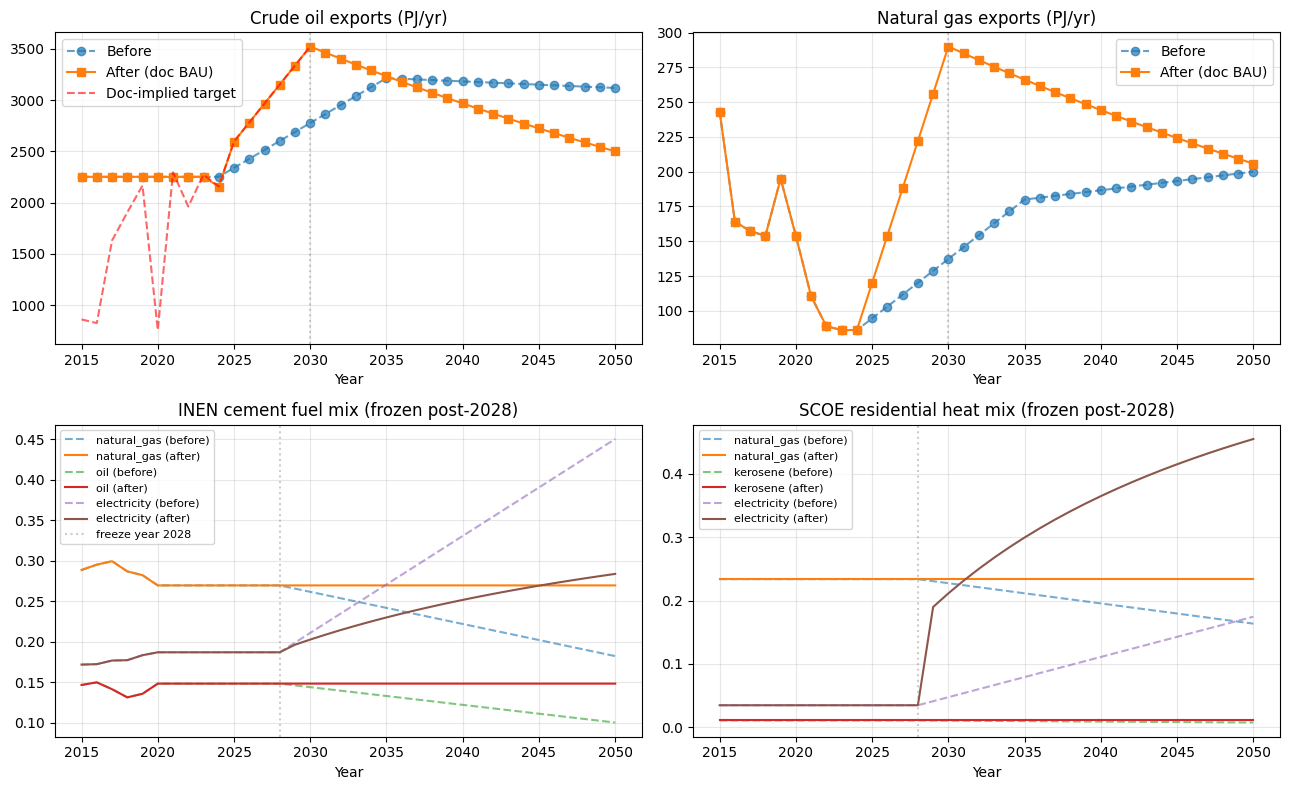

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
ax.plot(df["year"], df["exports_enfu_pj_fuel_crude"], "--o", label="Before", alpha=0.7)
ax.plot(df_new["year"], df_new["exports_enfu_pj_fuel_crude"], "-s", label="After (doc BAU)")
ax.plot(DOC_BAU["year"], DOC_BAU["crude_exports_pj_target"], "--", color="red", alpha=0.6,
        label="Doc-implied target")
ax.axvline(DOC_END_YEAR, color="gray", ls=":", alpha=0.4)
ax.set_title("Crude oil exports (PJ/yr)"); ax.set_xlabel("Year"); ax.grid(alpha=0.3); ax.legend()

ax = axes[0, 1]
ax.plot(df["year"], df["exports_enfu_pj_fuel_natural_gas"], "--o", label="Before", alpha=0.7)
ax.plot(df_new["year"], df_new["exports_enfu_pj_fuel_natural_gas"], "-s", label="After (doc BAU)")
ax.axvline(DOC_END_YEAR, color="gray", ls=":", alpha=0.4)
ax.set_title("Natural gas exports (PJ/yr)"); ax.set_xlabel("Year"); ax.grid(alpha=0.3); ax.legend()

# Example INEN subsector (cement) — has both natural_gas and oil fractions
ax = axes[1, 0]
for fuel in ["natural_gas", "oil", "electricity"]:
    c = f"frac_inen_energy_cement_{fuel}"
    ax.plot(df["year"], df[c], "--", alpha=0.6, label=f"{fuel} (before)")
    ax.plot(df_new["year"], df_new[c], "-", label=f"{fuel} (after)")
ax.axvline(FREEZE_YEAR, color="gray", ls=":", alpha=0.4, label=f"freeze year {FREEZE_YEAR}")
ax.set_title("INEN cement fuel mix (frozen post-2028)"); ax.set_xlabel("Year"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

# SCOE residential heat mix — no "oil" column; use natural_gas, kerosene, electricity
ax = axes[1, 1]
for fuel in ["natural_gas", "kerosene", "electricity"]:
    c = f"frac_scoe_heat_energy_residential_{fuel}"
    ax.plot(df["year"], df[c], "--", alpha=0.6, label=f"{fuel} (before)")
    ax.plot(df_new["year"], df_new[c], "-", label=f"{fuel} (after)")
ax.axvline(FREEZE_YEAR, color="gray", ls=":", alpha=0.4)
ax.set_title("SCOE residential heat mix (frozen post-2028)"); ax.set_xlabel("Year"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## Step 6 — Back-of-the-envelope emissions check

Use the (constant) fugitive emission factors from the current input to estimate production-driven fugitive emissions under the new crude-export trajectory, and compare to the document's target. This is only approximate because SSP adds venting and fugitive components with their own EFs, and because fugitive accounting also includes domestic production (not just exports).

In [28]:
# Emission factors (tonne CO2 / m3 fuel crude) for the flaring component, constant across years.
ef_co2_flar_crude = float(df.loc[df.year == 2024, "ef_fgtv_production_flaring_tonne_co2_per_m3_fuel_crude"].iloc[0])
ef_ch4_flar_crude = float(df.loc[df.year == 2024, "ef_fgtv_production_flaring_tonne_ch4_per_m3_fuel_crude"].iloc[0])
ef_ch4_vent_crude = float(df.loc[df.year == 2024, "ef_fgtv_production_venting_tonne_ch4_per_m3_fuel_crude"].iloc[0])
ef_ch4_fug_crude = float(df.loc[df.year == 2024, "ef_fgtv_production_fugitive_tonne_ch4_per_m3_fuel_crude"].iloc[0])

# Convert PJ of crude -> m3 of crude fuel.
#   1 PJ = 1e15 J;  1 m3 crude ~ 6.119 GJ/bbl / (159 L/bbl) * 1000 L/m3 = 38.48 GJ/m3 = 3.848e10 J/m3
#   So m3 = PJ * 1e15 / 3.848e10 = PJ * 2.599e4
PJ_TO_M3_CRUDE = 1e15 / (6.119e9 / 0.159)   # 0.159 m3/bbl

# Use full production (= exports / export_share) as the fugitive driver, not just exports.
prod_pj_new = df_new["exports_enfu_pj_fuel_crude"] / EXPORT_SHARE_CRUDE
prod_m3_new = prod_pj_new * PJ_TO_M3_CRUDE

# CH4 -> CO2e using GWP100 = 28 (adjust to 84 for 20-yr if desired)
GWP_CH4 = 28.0
flar_co2_mt = prod_m3_new * ef_co2_flar_crude / 1e6
flar_ch4_co2e_mt = prod_m3_new * ef_ch4_flar_crude * GWP_CH4 / 1e6
vent_ch4_co2e_mt = prod_m3_new * ef_ch4_vent_crude * GWP_CH4 / 1e6
fug_ch4_co2e_mt = prod_m3_new * ef_ch4_fug_crude * GWP_CH4 / 1e6

check = pd.DataFrame({
    "year": df_new["year"],
    "crude_prod_pj": prod_pj_new.values,
    "flar_co2_mt": flar_co2_mt.values,
    "flar_ch4_co2e_mt": flar_ch4_co2e_mt.values,
    "vent_ch4_co2e_mt": vent_ch4_co2e_mt.values,
    "fug_ch4_co2e_mt": fug_ch4_co2e_mt.values,
}).set_index("year")
check["total_fgtv_mt_co2e"] = check[["flar_co2_mt", "flar_ch4_co2e_mt", "vent_ch4_co2e_mt", "fug_ch4_co2e_mt"]].sum(axis=1)
check.loc[[2020, 2024, 2026, 2028, 2030, 2032, 2035, 2040, 2050]].round(2)

,crude_prod_pj,flar_co2_mt,flar_ch4_co2e_mt,vent_ch4_co2e_mt,fug_ch4_co2e_mt,total_fgtv_mt_co2e
year,,,,,,
2020,2712.09,2.82,0.05,20.16,18.24,41.27
2024,2598.09,2.70,0.05,19.31,17.47,39.53
2026,3350.15,3.48,0.06,24.91,22.53,50.98
2028,3796.84,3.94,0.07,28.23,25.54,57.77
2030,4243.53,4.41,0.08,31.55,28.54,64.57
2032,4100.47,4.26,0.07,30.48,27.58,62.39
2035,3894.88,4.05,0.07,28.95,26.20,59.27
2040,3574.89,3.71,0.06,26.58,24.04,54.40
2050,3011.60,3.13,0.05,22.39,20.26,45.83


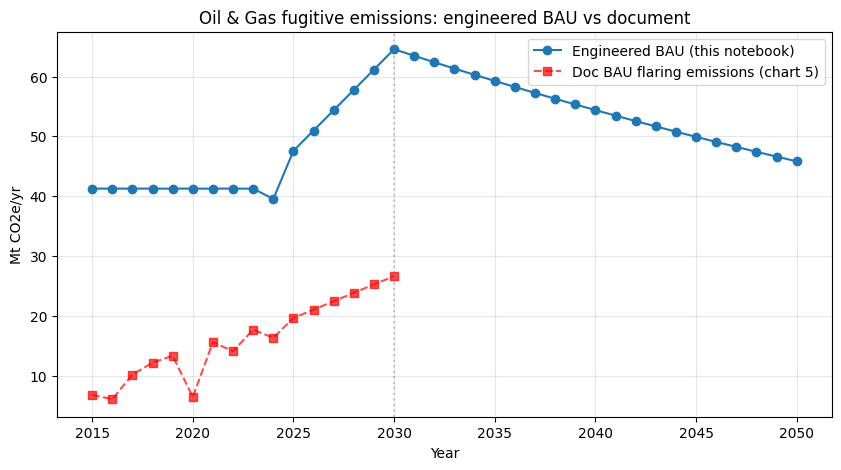

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(check.index, check["total_fgtv_mt_co2e"], "-o", label="Engineered BAU (this notebook)")
ax.plot(DOC_BAU["year"], DOC_BAU["flaring_emis_mt_bau"], "--s", color="red", alpha=0.7,
        label="Doc BAU flaring emissions (chart 5)")
ax.axvline(DOC_END_YEAR, color="gray", ls=":", alpha=0.4)
ax.set_title("Oil & Gas fugitive emissions: engineered BAU vs document")
ax.set_xlabel("Year"); ax.set_ylabel("Mt CO2e/yr"); ax.grid(alpha=0.3); ax.legend()
plt.show()
# Note: the engineered BAU includes venting + fugitive leaks + flaring CO2 + flaring CH4.
# The document's chart 5 tracks flaring emissions only, so our line should sit ABOVE the red series.

## Step 7 — Save the calibrated input CSV

In [30]:
# Sanity: column set and row count unchanged
assert df_new.shape == df.shape
assert list(df_new.columns) == list(df.columns)

df_new.to_csv(OUTPUT_FILE, index=False)
print(f"Wrote {OUTPUT_FILE}  |  shape {df_new.shape}")

Wrote sisepuede_raw_inputs_oilgas_bau_calibrated.csv  |  shape (36, 2441)


## Next steps

1. Point `config.yaml` → `input_data_file: sisepuede_raw_inputs_oilgas_bau_calibrated.csv` and run `libya_manager_wb_gas_recovery.ipynb` on strategy 0 (BASE) only to isolate the BAU effect.
2. Compare the resulting MODEL_OUTPUT fugitive emissions (rows for strategy `0`) against `DOC_BAU["flaring_emis_mt_bau"]` plus a +40% allowance for venting + fugitive-leak components.
3. If the 2030 total is still below ~36-38 Mt CO2e, iterate on:
   - `EXPORT_SHARE_CRUDE` (lowering it increases implied production for a given export volume)
   - `POST_2030_OIL_ANNUAL_CHANGE` (tunes the slope post-2030)
   - `FREEZE_YEAR` (earlier freeze -> stronger BAU)
4. Once BAU matches, rerun NDC strategies (6004, 6005) on the same input CSV to recompute abatement as (BAU − NDC) on the calibrated baseline.